In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
TARGET_COL = "Energy_Consumption_kWh"
VAL_RATIO = 0.15
TEST_RATIO = 0.15
ARTIFACTS_DIR = os.path.join("..", "artifacts")
PROCESSED_DIR = os.path.join("..", "data", "processed")

RENAME_MAP = {
    "Distance_Travelled_km": "length",
    "Slope_%": "gradient",
    "Road_Type": "surface_type",
    "Traffic_Condition": "traffic_density",
    "Temperature_C": "temperature",
    "Wind_Speed_ms": "wind_speed",
    "Weather_Condition": "weather_condition",
    "Speed_kmh": "speed_kmh",
    "Battery_State_%": "battery_soc",
    "Acceleration_ms2": "acceleration",
}

CATEGORICAL_COLS = ["surface_type", "traffic_density", "weather_condition"]
NUMERICAL_COLS = ["length", "gradient", "temperature", "wind_speed",
                    "speed_kmh", "battery_soc", "acceleration"]
ENGINEERED_COLS = ["gradient_sq", "length_x_gradient", "cold_penalty",
                    "wind_speed_sq", "speed_sq", "power_proxy", "speed_x_length"]
FEATURE_COLS = NUMERICAL_COLS + CATEGORICAL_COLS + ENGINEERED_COLS
META_COLS = ["vehicle_id", "timestamp"]


## Data Loading

The raw CSV is loaded directly from `energy-model/data/raw/EV_Energy_Consumption_Dataset.csv`. `Vehicle_ID` and `Timestamp` are carried as metadata — not model features.

In [2]:
csv_path = os.path.join("..", "data", "raw", "EV_Energy_Consumption_Dataset.csv")
df = pd.read_csv(csv_path)

print(f"CSV: {csv_path}")
print(f"Shape: {df.shape}")
df.head(3).T

CSV: ../data/raw/EV_Energy_Consumption_Dataset.csv
Shape: (5000, 19)


,0,1,2
Vehicle_ID,1102,1435,1860
Timestamp,2024-01-01 00:00:00,2024-01-01 00:01:00,2024-01-01 00:02:00
Speed_kmh,111.5074,48.6123,108.7333
Acceleration_ms2,-2.7738,-0.7970,0.2538
Battery_State_%,30.4151,97.3855,84.9126
Battery_Voltage_V,378.0915,392.7184,398.9935
Battery_Temperature_C,25.3148,18.2408,44.4491
Driving_Mode,2,1,1
Road_Type,1,2,1
Traffic_Condition,1,1,3


## Feature Selection & Renaming

Ten inference-available base features and the target are selected.
`Vehicle_ID` and `Timestamp` pass through as metadata.

In [3]:
INFERENCE_COLS = list(RENAME_MAP.keys())
df_selected = df[INFERENCE_COLS + [TARGET_COL, "Vehicle_ID", "Timestamp"]].copy()
df_selected = df_selected.rename(columns={
    **RENAME_MAP,
    "Vehicle_ID": "vehicle_id",
    "Timestamp": "timestamp",
})

inverse_map = {v: k for k, v in RENAME_MAP.items()}
print(f"Feature columns ({len(INFERENCE_COLS)}):")
for col in INFERENCE_COLS:
    print(f"{RENAME_MAP[col]:<22} <- {col}")
print(f"\nMetadata: vehicle_id, timestamp (not features)")
print(f"Shape after selection: {df_selected.shape}")

Feature columns (10):
length                 <- Distance_Travelled_km
gradient               <- Slope_%
surface_type           <- Road_Type
traffic_density        <- Traffic_Condition
temperature            <- Temperature_C
wind_speed             <- Wind_Speed_ms
weather_condition      <- Weather_Condition
speed_kmh              <- Speed_kmh
battery_soc            <- Battery_State_%
acceleration           <- Acceleration_ms2

Metadata: vehicle_id, timestamp (not features)
Shape after selection: (5000, 13)


## Feature Engineering

Seven physics-motivated features are derived from inference-available base features.
`speed_x_length` (|r|=0.822) is the strongest single predictor — it approximates
aerodynamic drag energy as force × distance ∝ v × d.

In [4]:
df_fe = df_selected.copy()

df_fe["gradient_sq"] = df_fe["gradient"] ** 2
df_fe["length_x_gradient"] = df_fe["length"] * df_fe["gradient"].abs()
df_fe["cold_penalty"] = np.maximum(0.0, -df_fe["temperature"])
df_fe["wind_speed_sq"] = df_fe["wind_speed"] ** 2
df_fe["speed_sq"] = df_fe["speed_kmh"] ** 2
df_fe["power_proxy"] = df_fe["speed_kmh"] / 3.6 * df_fe["acceleration"].abs()
df_fe["speed_x_length"] = df_fe["speed_kmh"] * df_fe["length"]

print(f"Feature matrix shape: {df_fe[FEATURE_COLS].shape}")
print(f"\nEngineered feature stats:")
print(df_fe[ENGINEERED_COLS].describe().T[["mean", "std", "min", "max"]].round(4))

Feature matrix shape: (5000, 17)

Engineered feature stats:
                       mean       std    min        max
gradient_sq         25.2867   27.6878 0.0000    99.9672
length_x_gradient  104.7287   98.6936 0.0067   489.7205
cold_penalty         0.2853    0.9435 0.0000     4.9953
wind_speed_sq       75.0322   66.9738 0.0000   224.9729
speed_sq          4709.2530 4274.1059 0.0000 14387.2647
power_proxy         24.5902   21.8566 0.0000    99.0717
speed_x_length    1488.5527 1299.6914 0.0169  5844.5516


## Target Transformation

Skewness is evaluated at runtime. Original skewness is ~0.02 (near-normal),
so `log1p` will not be applied — confirmed by the runtime check below.

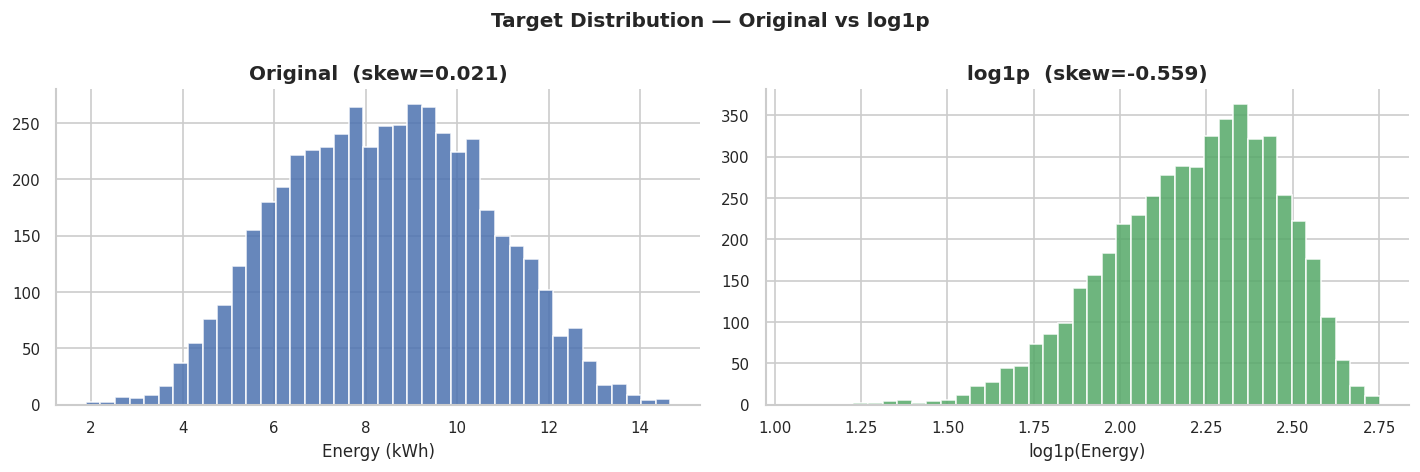

log1p applied : False  (skew 0.0206 -> -0.5588)


In [5]:
skew_orig = df_fe[TARGET_COL].skew()
skew_log = np.log1p(df_fe[TARGET_COL]).skew()
apply_log1p = abs(skew_log) < abs(skew_orig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_fe[TARGET_COL], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title(f"Original  (skew={skew_orig:.3f})", fontweight="bold")
axes[0].set_xlabel("Energy (kWh)")
log_vals = np.log1p(df_fe[TARGET_COL])
axes[1].hist(log_vals, bins=40, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].set_title(f"log1p  (skew={skew_log:.3f})", fontweight="bold")
axes[1].set_xlabel("log1p(Energy)")
plt.suptitle("Target Distribution — Original vs log1p", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

if apply_log1p:
    df_fe[TARGET_COL] = np.log1p(df_fe[TARGET_COL])
print(f"log1p applied : {apply_log1p}  (skew {skew_orig:.4f} -> {skew_log:.4f})")

## Train / Val / Test Split

70 / 15 / 15 split with fixed seed. **All fit-based steps run on `df_train` only.**

In [6]:
df_trainval, df_test = train_test_split(
    df_fe, test_size=TEST_RATIO, random_state=RANDOM_STATE, shuffle=True,
)
val_ratio_adjusted = VAL_RATIO / (1.0 - TEST_RATIO)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_ratio_adjusted, random_state=RANDOM_STATE, shuffle=True,
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

total = len(df_fe)
print(f"Total: {total}")
print(f"Train: {len(df_train)}  ({len(df_train)/total*100:.1f}%)")
print(f"Val: {len(df_val)}  ({len(df_val)/total*100:.1f}%)")
print(f"Test: {len(df_test)}  ({len(df_test)/total*100:.1f}%)")
print(
    f"Target mean -- "
    f"Train: {df_train[TARGET_COL].mean():.4f} | "
    f"Val: {df_val[TARGET_COL].mean():.4f} | "
    f"Test: {df_test[TARGET_COL].mean():.4f}"
)

Total: 5000
Train: 3500  (70.0%)
Val: 750  (15.0%)
Test: 750  (15.0%)
Target mean -- Train: 8.4170 | Val: 8.5263 | Test: 8.4478


## Categorical Encoding

Remapped to zero-indexed integers based on **train set only**.

In [7]:
encoders = {}
for col in CATEGORICAL_COLS:
    unique_vals = sorted(df_train[col].unique())
    encoders[col] = {int(v): i for i, v in enumerate(unique_vals)}
    df_train[col] = df_train[col].map(encoders[col])
    df_val[col] = df_val[col].map(encoders[col])
    df_test[col] = df_test[col].map(encoders[col])

encoders["meta"] = {"apply_log1p": bool(apply_log1p), "target_col": TARGET_COL}

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
encoder_path = os.path.join(ARTIFACTS_DIR, "encoders.pkl")
with open(encoder_path, "wb") as fh:
    pickle.dump(encoders, fh)

print(f"Saved: {encoder_path}  ({os.path.getsize(encoder_path)} bytes)")
for col, mapping in encoders.items():
    if col != "meta":
        print(f"  {col}: {mapping}")
print(f"meta: {encoders['meta']}")

Saved: ../artifacts/encoders.pkl  (185 bytes)
  surface_type: {1: 0, 2: 1, 3: 2}
  traffic_density: {1: 0, 2: 1, 3: 2}
  weather_condition: {1: 0, 2: 1, 3: 2, 4: 3}
meta: {'apply_log1p': False, 'target_col': 'Energy_Consumption_kWh'}


## Feature Scaling

`StandardScaler` fitted **on `df_train` only**. All 17 features scaled together.

Saved : ../artifacts/scaler.pkl  (824 bytes)

Leakage check:
Scaler mean[speed_kmh]: 59.3661  (train)
Raw val mean[speed_kmh]: 60.6568  (different -- correct)


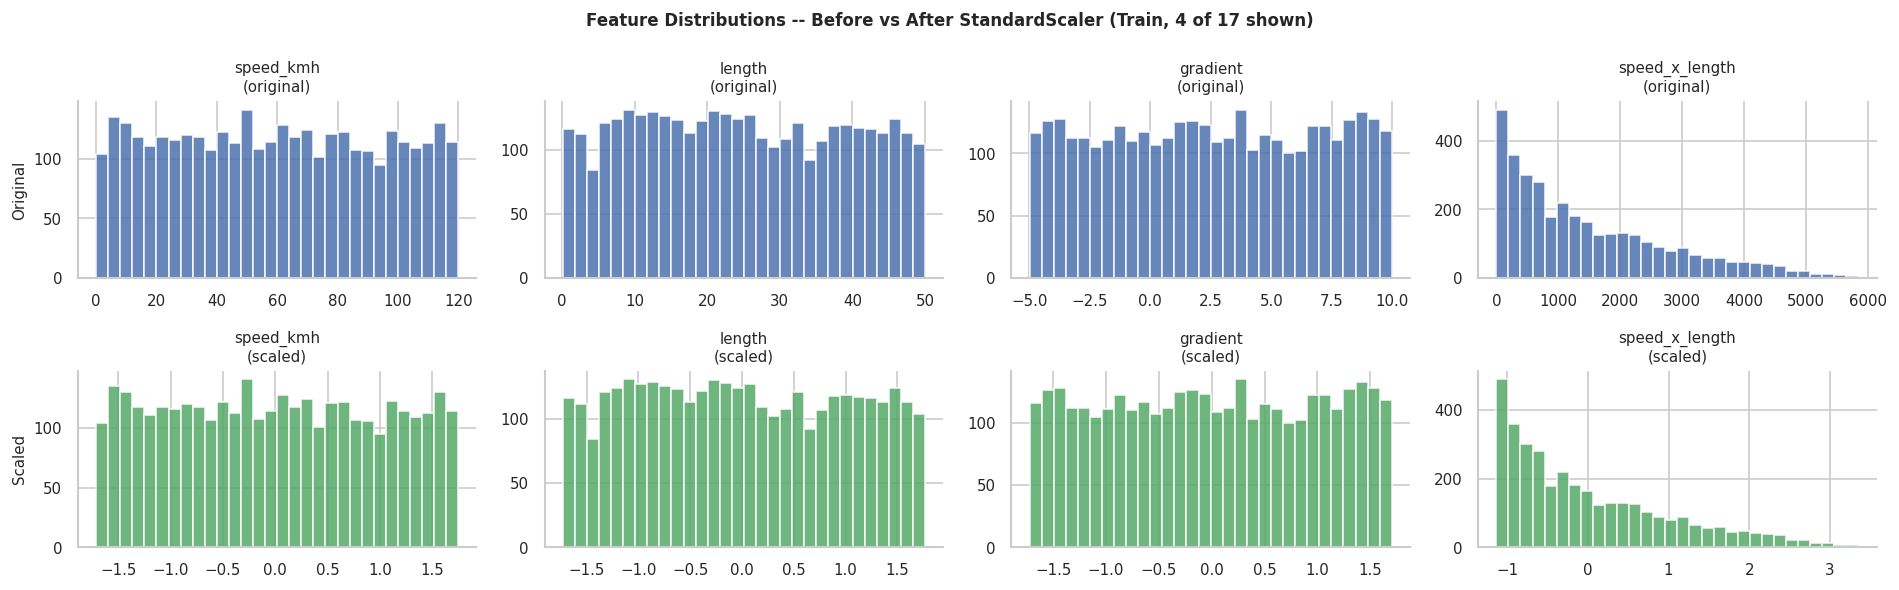

In [8]:
scaler = StandardScaler()
X_train = df_train[FEATURE_COLS].values.astype("float32")
X_val   = df_val[FEATURE_COLS].values.astype("float32")
X_test  = df_test[FEATURE_COLS].values.astype("float32")

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

scaler_path = os.path.join(ARTIFACTS_DIR, "scaler.pkl")
with open(scaler_path, "wb") as fh:
    pickle.dump(scaler, fh)

print(f"Saved : {scaler_path}  ({os.path.getsize(scaler_path)} bytes)")
speed_idx = FEATURE_COLS.index("speed_kmh")
print(f"\nLeakage check:")
print(f"Scaler mean[speed_kmh]: {scaler.mean_[speed_idx]:.4f}  (train)")
print(f"Raw val mean[speed_kmh]: {df_val['speed_kmh'].mean():.4f}  (different -- correct)")

PLOT_COLS = ["speed_kmh", "length", "gradient", "speed_x_length"]
fig, axes = plt.subplots(2, 4, figsize=(16, 5))
for idx, col in enumerate(PLOT_COLS):
    fi = FEATURE_COLS.index(col)
    axes[0, idx].hist(X_train[:, fi], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[0, idx].set_title(f"{col}\n(original)", fontsize=9)
    axes[1, idx].hist(X_train_scaled[:, fi], bins=30, color="#55A868", edgecolor="white", alpha=0.85)
    axes[1, idx].set_title(f"{col}\n(scaled)", fontsize=9)
axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Scaled", fontsize=9)
plt.suptitle("Feature Distributions -- Before vs After StandardScaler (Train, 4 of 17 shown)",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

## Processed Data Export

Scaled features + target + metadata saved to `energy-model/data/processed/`. NB3 (graph construction) reads these three CSVs as its input.

In [9]:
def build_processed_df(X_scaled, y, vehicle_ids, timestamps):
    frame = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
    frame[TARGET_COL]    = y.values
    frame["vehicle_id"]  = vehicle_ids.values
    frame["timestamp"]   = timestamps.values
    return frame

df_train_out = build_processed_df(X_train_scaled, df_train[TARGET_COL], df_train["vehicle_id"], df_train["timestamp"])
df_val_out   = build_processed_df(X_val_scaled,   df_val[TARGET_COL],   df_val["vehicle_id"],   df_val["timestamp"])
df_test_out  = build_processed_df(X_test_scaled,  df_test[TARGET_COL],  df_test["vehicle_id"],  df_test["timestamp"])

os.makedirs(PROCESSED_DIR, exist_ok=True)
train_path = os.path.join(PROCESSED_DIR, "train_processed.csv")
val_path   = os.path.join(PROCESSED_DIR, "val_processed.csv")
test_path  = os.path.join(PROCESSED_DIR, "test_processed.csv")

df_train_out.to_csv(train_path, index=False)
df_val_out.to_csv(val_path,     index=False)
df_test_out.to_csv(test_path,   index=False)

for path, split, frame in [
    (train_path, "Train", df_train_out),
    (val_path,   "Val",   df_val_out),
    (test_path,  "Test",  df_test_out),
]:
    print(f"Saved {split:<6}: {path}  shape={frame.shape}")

Saved Train : ../data/processed/train_processed.csv  shape=(3500, 20)
Saved Val   : ../data/processed/val_processed.csv  shape=(750, 20)
Saved Test  : ../data/processed/test_processed.csv  shape=(750, 20)


## Preprocessing Summary

In [10]:
summary = {
    "total_samples": len(df_fe),
    "train_samples": len(df_train_out),
    "val_samples": len(df_val_out),
    "test_samples": len(df_test_out),
    "feature_count": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "log1p_applied": bool(apply_log1p),
    "encoders_path": os.path.join(ARTIFACTS_DIR, "encoders.pkl"),
    "scaler_path": os.path.join(ARTIFACTS_DIR, "scaler.pkl"),
}

print("=" * 62)
print("PREPROCESSING SUMMARY")
print("=" * 62)
for k, v in summary.items():
    print(f"  {k}: {v}")
print("=" * 62)
print("\nHandoff to: EV Energy -- Graph Construction & PyTorch Geometric")
print(f"Node feature dim : {len(FEATURE_COLS)}")
print(f"kNN graph cols   : speed_kmh, length, gradient")

PREPROCESSING SUMMARY
  total_samples: 5000
  train_samples: 3500
  val_samples: 750
  test_samples: 750
  feature_count: 17
  feature_cols: ['length', 'gradient', 'temperature', 'wind_speed', 'speed_kmh', 'battery_soc', 'acceleration', 'surface_type', 'traffic_density', 'weather_condition', 'gradient_sq', 'length_x_gradient', 'cold_penalty', 'wind_speed_sq', 'speed_sq', 'power_proxy', 'speed_x_length']
  log1p_applied: False
  encoders_path: ../artifacts/encoders.pkl
  scaler_path: ../artifacts/scaler.pkl

Handoff to: EV Energy -- Graph Construction & PyTorch Geometric
Node feature dim : 17
kNN graph cols   : speed_kmh, length, gradient
